# Zomato Restaurant Data Analysis

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('zomato_data.csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


## Initial Analysis

In [25]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [26]:
df.shape

(148, 7)

In [27]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [28]:
df.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

In [29]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


## Data Cleaning

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [32]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [54]:
df = df.dropna()
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [33]:
df['rate']

0      4.1/5
1      4.1/5
2      3.8/5
3      3.7/5
4      3.8/5
       ...  
143    3.3/5
144    3.3/5
145    4.0/5
146    3.0/5
147    3.9/5
Name: rate, Length: 148, dtype: object

In [34]:
df['rate'].value_counts()

rate
3.8/5     19
3.7/5     15
3.3/5     14
3.4/5     12
4.1/5     11
3.6/5     11
4.0/5     10
3.9/5     10
4.2/5      8
3.1/5      7
2.9/5      7
3.2/5      7
3.5/5      6
3.0/5      2
4.6/5      2
2.8/5      2
4.4/5      2
4.3/5      1
2.6/5      1
3.8 /5     1
Name: count, dtype: int64

In [35]:
df['rate'] = df['rate'].str.replace(' ', '', regex=False)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [37]:
df['rate'].value_counts()

rate
3.8    20
3.7    15
3.3    14
3.4    12
4.1    11
3.6    11
4.0    10
3.9    10
4.2     8
3.1     7
3.2     7
2.9     7
3.5     6
4.6     2
2.8     2
4.4     2
3.0     2
4.3     1
2.6     1
Name: count, dtype: int64

In [38]:
print(df['rate'].head())
print(df['rate'].dtype)

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64
float64


In [39]:
df['rate'].min()

2.6

In [40]:
df['rate'].max()

4.6

## Exploratory Data Analysis

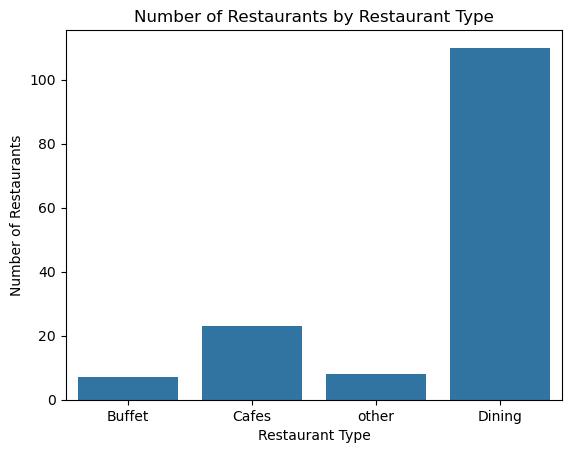

In [44]:
sns.countplot(data=df, x='listed_in(type)')
plt.title('Number of Restaurants by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')
plt.show()

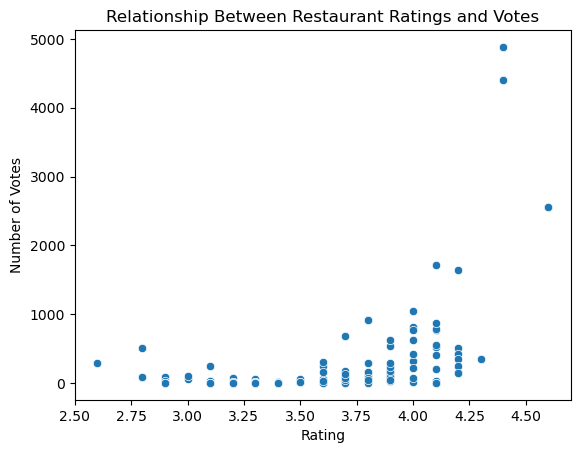

In [43]:
sns.scatterplot(data=df, x='rate', y='votes')
plt.title('Relationship Between Restaurant Ratings and Votes')
plt.xlabel('Rating')
plt.ylabel('Number of Votes')
plt.show()

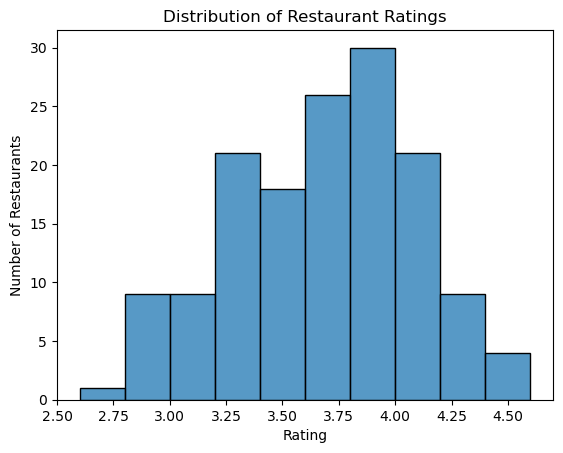

In [45]:
sns.histplot(data=df, x='rate', bins=10)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

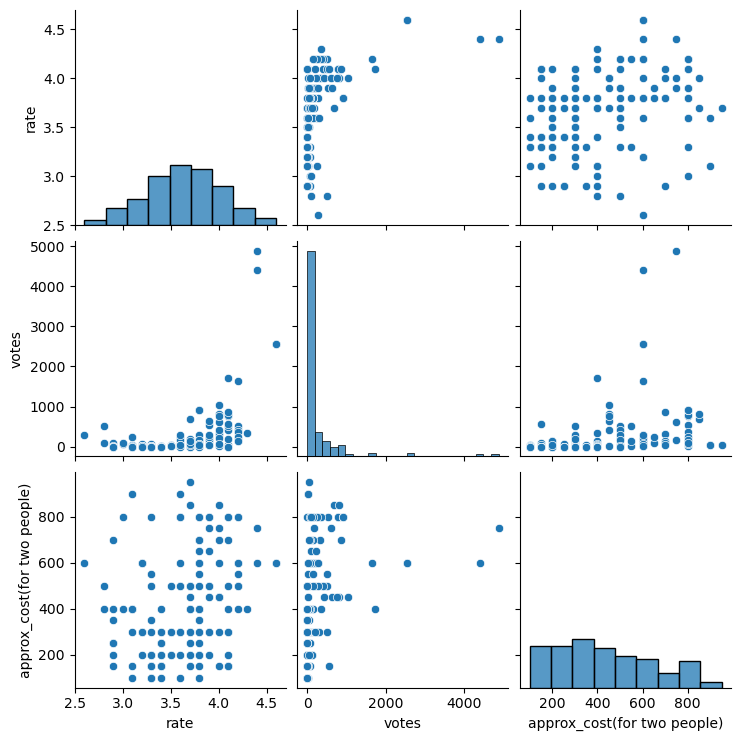

In [46]:
sns.pairplot(df[['rate', 'votes', 'approx_cost(for two people)']])
plt.show()

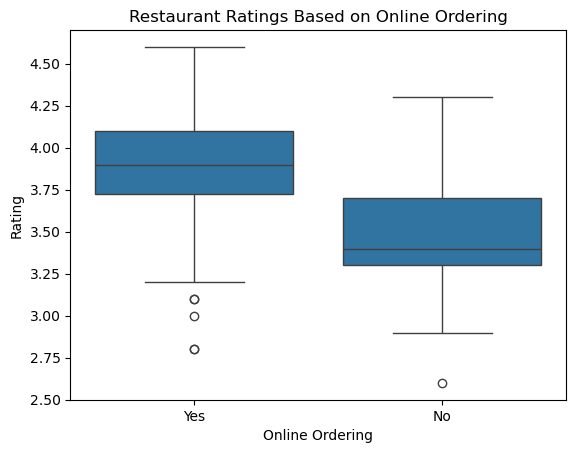

In [47]:
sns.boxplot(data=df,x='online_order',y='rate')
plt.title('Restaurant Ratings Based on Online Ordering')
plt.xlabel('Online Ordering')
plt.ylabel('Rating')
plt.show()

In [50]:
df['rate'].value_counts().head()

rate
3.8    20
3.7    15
3.3    14
3.4    12
4.1    11
Name: count, dtype: int64

In [51]:
df['rate'].apply(lambda x: 'Positive' if x >= 4 else 'Negative').value_counts()

rate
Negative    114
Positive     34
Name: count, dtype: int64

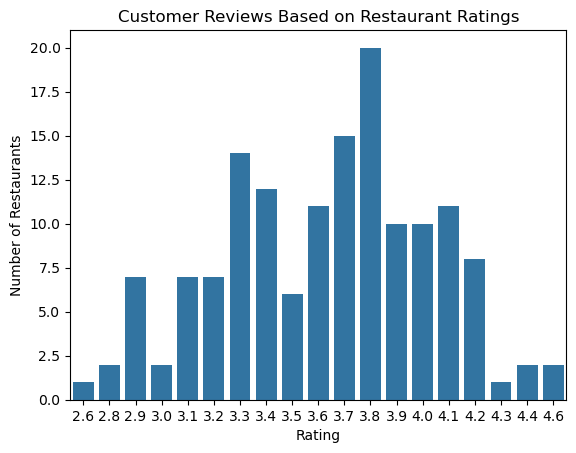

In [52]:
sns.countplot(data=df, x='rate')
plt.title('Customer Reviews Based on Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()